In [1]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from transformers import (BertTokenizer, BertForSequenceClassification,
                          RobertaTokenizer, RobertaForSequenceClassification,
                          DistilBertTokenizer, DistilBertForSequenceClassification)
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os, gc, time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch.backends.cudnn.benchmark = True  # optimize cuDNN performance


c:\Users\hunny\anaconda3\envs\nlp_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda - NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
%conda install -c conda-forge transformers


Retrieving notices: done
Channels:
 - conda-forge
 - defaults
 - nvidia
 - pytorch
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: c:\Users\hunny\anaconda3\envs\nlp_gpu

  added / updated specs:
    - transformers


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.11.12 |       h4c7d964_0         149 KB  conda-forge
    certifi-2025.11.12         |     pyhd8ed1ab_0         153 KB  conda-forge
    ------------------------------------------------------------
                                           Total:         303 KB

The following packages will be UPDATED:

  ca-certificates    pkgs/main/win-64::ca-certificates-202~ --> conda-forge/noarch::ca-certificates-2025.11.12-h4c7d964_0 
  certifi                            2025.10.5-pyhd8ed1ab_0 --> 2025.11.12-pyhd8ed1ab_0 



certifi-2025.11.12   | 153 KB    |         

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'ReadTimeoutError("HTTPSConnectionPool(host='repo.anaconda.com', port=443): Read timed out. (read timeout=5)")': /pkgs/main/notices.json



In [15]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df = train_df[['text', 'label']].copy()
test_df = test_df[['text', 'label']].copy()

train_df = train_df.sample(100000, random_state=42).reset_index(drop=True)
test_df = test_df.sample(25000, random_state=42).reset_index(drop=True)



for df in [train_df, test_df]:
    if 'Unnamed: 0' in df.columns:
        df.drop(columns=['Unnamed: 0'], inplace=True)

le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['label'])
test_df['label'] = le.transform(test_df['label'])

X_train, y_train = train_df['text'].tolist(), train_df['label'].tolist()
X_test, y_test = test_df['text'].tolist(), test_df['label'].tolist()

num_labels = len(le.classes_)

In [16]:
bert_tok = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_labels)

roberta_tok = RobertaTokenizer.from_pretrained("roberta-base")
roberta_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=num_labels)

distil_tok = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
distil_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=num_labels)

models = [bert_model, roberta_model, distil_model]
tokenizers = [bert_tok, roberta_tok, distil_tok]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and infe

In [17]:
for model in models:
    model.to(device)

In [18]:
class EnsDataset(Dataset):
    def __init__(self, encodings_list, labels):
        self.encodings_list = encodings_list
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return [{k: v[idx] for k, v in enc.items()} for enc in self.encodings_list], torch.tensor(self.labels[idx])


# Tokenize training and test data
train_encodings = [tok(X_train, truncation=True, padding=True, max_length=64, return_tensors="pt") for tok in tokenizers]
test_encodings = [tok(X_test, truncation=True, padding=True, max_length=64, return_tensors="pt") for tok in tokenizers]

# Now define the datasets
train_dataset = EnsDataset(train_encodings, y_train)
test_dataset = EnsDataset(test_encodings, y_test)


In [19]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

optimizers = [AdamW(model.parameters(), lr=5e-5) for model in models]

scaler = torch.cuda.amp.GradScaler()


C:\Users\hunny\AppData\Local\Temp\ipykernel_31808\2967918764.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [20]:
EPOCHS = 3
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    for batch in tqdm(train_loader, desc="Training", leave=False):
        batch_enc, labels = batch
        labels = labels.to(device)
        for enc, opt, model in zip(batch_enc, optimizers, models):
            opt.zero_grad()
            enc = {k: v.to(device) for k, v in enc.items()}
            with torch.cuda.amp.autocast():
                out = model(**enc, labels=labels)
                loss = out.loss
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()


Epoch 1/3


Training:   0%|          | 0/12500 [00:00<?, ?it/s]C:\Users\hunny\AppData\Local\Temp\ipykernel_31808\3913254499.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 2/3



Epoch 3/3


In [21]:
all_preds = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Inference", leave=False):
        batch_enc, _ = batch
        batch_logits = []
        for enc, model in zip(batch_enc, models):
            enc = {k: v.to(device) for k, v in enc.items()}
            out = model(**enc)
            batch_logits.append(out.logits.cpu())
        avg_logits = torch.stack(batch_logits).mean(0)
        preds = torch.argmax(avg_logits, dim=-1).numpy()
        all_preds.extend(preds)

acc = accuracy_score(y_test, all_preds)
print(f"Validation Accuracy: {acc:.4f}")

Validation Accuracy: 0.8693


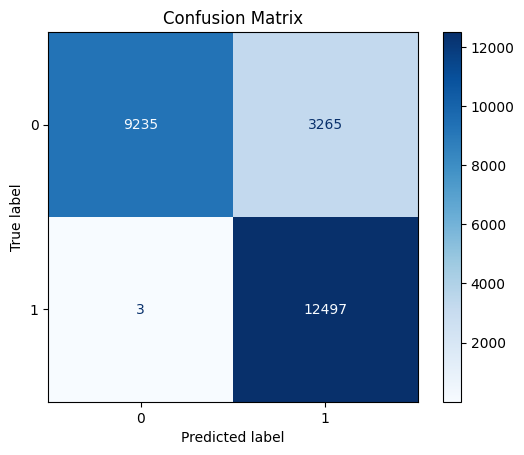

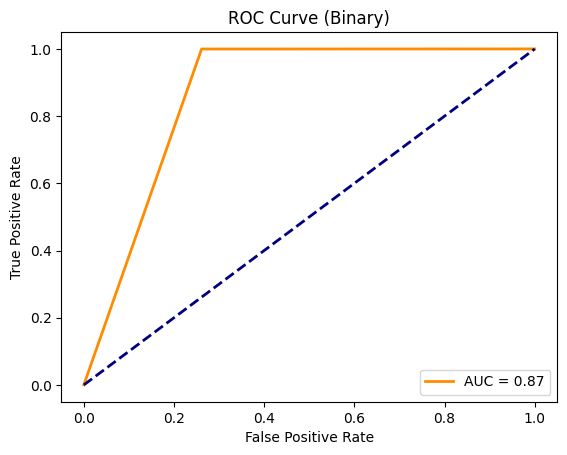

In [22]:
# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# ROC Curve
# -------------------------
if num_labels == 2:
    fpr, tpr, _ = roc_curve(y_test, all_preds)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Binary)')
    plt.legend(loc="lower right")
    plt.show()
else:
    y_test_bin = label_binarize(y_test, classes=range(num_labels))
    preds_bin = label_binarize(all_preds, classes=range(num_labels))
    plt.figure()
    for i in range(num_labels):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], preds_bin[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"{le.classes_[i]} (AUC {roc_auc:.2f})")
    plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Multi-class)')
    plt.legend(loc="lower right")
    plt.show()


In [23]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Unique labels:", train_df['label'].nunique())
print("Example label distribution:")
print(train_df['label'].value_counts().head())

print(train_df.shape)
print(train_df.columns)



Train shape: (100000, 2)
Test shape: (25000, 2)
Unique labels: 2
Example label distribution:
label
0    50086
1    49914
Name: count, dtype: int64
(100000, 2)
Index(['text', 'label'], dtype='object')


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
for m in models:
    m.to(device)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=2)

optimizers = [AdamW(m.parameters(), lr=5e-5) for m in models]

Using device: cuda


In [13]:
def train_one_epoch(model, dataloader, optimizer, scaler):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader, desc="Training", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        with autocast():
            outputs = model(**batch)
            loss = outputs.loss
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate(model, dataloader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            preds.extend(torch.argmax(logits, dim=-1).cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())
    return accuracy_score(labels, preds), preds, labels

In [14]:
num_epochs = 3
val_acc_per_epoch = []

for epoch in range(1, num_epochs+1):
    print(f"Epoch {epoch}/{num_epochs}")
    for batch in tqdm(train_loader, desc="Training"):
        batch_enc, labels = batch
        labels = labels.to(device)

        # Zero grads for all models
        for opt in optimizers:
            opt.zero_grad()

        # Forward passes for all models and compute individual losses
        losses = []
        for enc, model in zip(batch_enc, models):
            enc = {k: v.to(device) for k, v in enc.items()}
            out = model(**enc, labels=labels)
            losses.append(out.loss)

        # Combine losses and backpropagate once
        total_loss = sum(losses) / len(losses)
        total_loss.backward()

        # Step optimizers
        for opt in optimizers:
            opt.step()

    # -------------------------
    # Validation after epoch
    # -------------------------
    all_preds = []
    with torch.no_grad():
        for batch in test_loader:
            batch_enc, _ = batch
            batch_logits = []
            for enc, model in zip(batch_enc, models):
                enc = {k: v.to(device) for k, v in enc.items()}
                out = model(**enc)
                batch_logits.append(out.logits.cpu())
            avg_logits = torch.stack(batch_logits).mean(0)
            pred = torch.argmax(avg_logits, dim=-1).numpy()
            all_preds.extend(pred)
    
    acc = accuracy_score(y_test, all_preds)
    val_acc_per_epoch.append(acc)
    print(f"Validation Accuracy: {acc:.4f}")

Epoch 1/3


Training:   0%|          | 0/5000 [00:05<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 6512, 34372) exited unexpectedly

In [ ]:
for model_name, tok_class, model_class in models_info:
    print(f"\n🧠 Training {model_name}...\n")
    tokenizer = tok_class.from_pretrained(model_name)
    model = model_class.from_pretrained(model_name, num_labels=num_labels).to(device)

    train_enc = tokenizer(X_train, truncation=True, padding=True, max_length=64, return_tensors="pt")
    test_enc = tokenizer(X_test, truncation=True, padding=True, max_length=64, return_tensors="pt")

    train_dataset = TextDataset(train_enc, y_train)
    test_dataset = TextDataset(test_enc, y_test)

    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=4)

    optimizer = AdamW(model.parameters(), lr=5e-5)
    scaler = GradScaler()

    start_epoch = 0
    checkpoint_path = f"{model_name.replace('/', '_')}_checkpoint.pt"

    # Resume if checkpoint exists
    if os.path.exists(checkpoint_path):
        print(f"🔁 Resuming from checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1

    num_epochs = 2
    val_acc_history = []

    for epoch in range(start_epoch, num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        val_acc, preds, labels = evaluate(model, test_loader)
        val_acc_history.append(val_acc)

        print(f"Loss: {train_loss:.4f} | Validation Accuracy: {val_acc:.4f}")

        # Save checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        }, checkpoint_path)
        print(f"💾 Saved checkpoint: {checkpoint_path}")

NameError: name 'models_info' is not defined

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "CPU")
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("Memory allocated (GB):", torch.cuda.memory_allocated(0) / 1e9)
    print("Memory reserved (GB):", torch.cuda.memory_reserved(0) / 1e9)


GPU available: True
Current device: 0
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Memory allocated (GB): 4.869705728
Memory reserved (GB): 6.094323712


In [ ]:
%timeit next(iter(train_loader))


5.5 ms ± 448 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# -------------------------
# ROC Curve
# -------------------------
y_test_bin = label_binarize(y_test, classes=list(range(num_labels)))
all_preds_bin = label_binarize(all_preds, classes=list(range(num_labels)))

plt.figure()
for i in range(num_labels):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_preds_bin[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend(loc="lower right")
plt.show()

# -------------------------
# Validation Curve
# -------------------------
epochs = list(range(1, num_epochs+1))
plt.figure()
plt.plot(epochs, val_acc_per_epoch, marker='o', linestyle='-', color='b')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Curve")
plt.xticks(epochs)
plt.grid(True)
plt.show()
